# Cross-Validation Strategy for Customer Churn Prediction

## Goal

The goal of this notebook is to build a supervised machine learning pipeline for customer churn prediction, with a special focus on cross-validation strategy.

The project uses the Telco Customer Churn dataset. Each row represents a customer, and the target variable indicates whether the customer churned.

Instead of only training one model and reporting one score, this notebook focuses on how model evaluation changes under different validation strategies.

The notebook explores:

- Holdout validation
- Stratified K-Fold cross-validation
- Repeated Stratified K-Fold
- Cross-validation score stability
- Hyperparameter tuning with cross-validation
- Nested cross-validation
- Final test-set evaluation
- Bootstrap confidence intervals
- Threshold tuning

The purpose is to learn how to make supervised model evaluation more reliable and less dependent on one lucky or unlucky train-test split.

In [1]:
import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset downloaded to:", path)
print("Files:")
print(os.listdir(path))

100%|██████████| 172k/172k [00:00<00:00, 287kB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
Files:
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [4]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]
csv_files

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [5]:
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset

This notebook uses the Telco Customer Churn dataset from Kaggle.

Each row represents one customer. The dataset contains customer demographic information, account information, subscribed services, payment information, charges, tenure, and whether the customer churned.

The target variable is `Churn`, where:

- `Yes` means the customer churned
- `No` means the customer did not churn

This is a supervised binary classification problem.

In [6]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## Initial Data Inspection

The dataset contains 7,043 customers and 21 columns.

The target variable is `Churn`. There are 5,174 customers who did not churn and 1,869 customers who churned.

The churn rate is approximately 26.54%.

The initial missing-value check does not show standard missing values. However, the `TotalCharges` column is stored as text, and some blank values are only revealed after converting it to a numeric column.

This dataset is suitable for studying cross-validation because it has enough rows for multiple train-validation splits and contains a realistic mix of numerical and categorical features.

In [7]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

Missing values after converting TotalCharges:
TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64


In [8]:
df_clean = df_clean.dropna(subset=["TotalCharges"]).reset_index(drop=True)

print("Shape after cleaning:", df_clean.shape)
print(df_clean["TotalCharges"].isna().sum())

Shape after cleaning: (7032, 21)
0


In [9]:
df_clean["ChurnBinary"] = df_clean["Churn"].map({"No": 0, "Yes": 1})

df_clean[["Churn", "ChurnBinary"]].head()

,Churn,ChurnBinary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [10]:
target_col = "ChurnBinary"

X = df_clean.drop(columns=["customerID", "Churn", target_col])
y = df_clean[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts(normalize=True))

X shape: (7032, 19)
y shape: (7032,)
ChurnBinary
0    0.734215
1    0.265785
Name: proportion, dtype: float64


## Data Cleaning

The `TotalCharges` column is converted from text to numeric values.

After conversion, 11 rows contain missing values in `TotalCharges`. These rows are removed because the number of affected rows is very small compared with the full dataset.

After cleaning, the dataset contains 7,032 customers.

The target variable is converted into a binary column called `ChurnBinary`:

- `0` = did not churn
- `1` = churned

The final feature matrix contains 7,032 rows and 19 features. The churn ratio after cleaning is approximately 26.58%, which is very close to the original dataset.

The `customerID` column is removed because it is only an identifier and should not be used as a predictive feature.

In [11]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Number of numeric columns: 4
Number of categorical columns: 15


## Feature Types

The final feature set contains 4 numerical columns and 15 categorical columns.

The numerical columns are `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`.

The categorical columns include customer demographics, contract type, internet service, payment method, billing type, and subscribed services.

A preprocessing pipeline is needed so that numerical and categorical columns are handled correctly inside cross-validation.

In [12]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest target ratio:")
print(y_test.value_counts(normalize=True))

Train shape: (5625, 19)
Test shape: (1407, 19)

Train target ratio:
ChurnBinary
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Test target ratio:
ChurnBinary
0    0.734186
1    0.265814
Name: proportion, dtype: float64


## Train-Test Split

The data is split into a training set and a final test set.

The final test set is kept separate and should not be used during model selection or hyperparameter tuning.

Stratification is used so that the churn ratio is similar in both the training and test sets.

This is important because churn prediction has class imbalance, and we want each split to represent both churned and non-churned customers fairly.

In [14]:
def evaluate_predictions(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
    }

In [17]:
def print_model_report(name, y_true, y_pred, y_prob):
    print(name)
    print("=" * len(name))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("PR-AUC:", average_precision_score(y_true, y_prob))

In [18]:
models = {
    "Dummy Prior": DummyClassifier(strategy="prior", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42
    )
}

In [19]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

model_pipelines

{'Dummy Prior': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('scaler',
                                                                    StandardScaler())]),
                                                   ['SeniorCitizen', 'tenure',
                                                    'MonthlyCharges',
                                                    'TotalCharges']),
                                                  ('cat',
                                                   Pipeline(steps=[('onehot',
                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                  sparse_output=False))]),
                                                   ['gender', 'Partner',
                                                    'Dependents', 'PhoneService',
  

## Models

This notebook compares several supervised classification models.

The dummy model is a baseline that predicts using the class prior. It helps show whether real models are learning useful patterns beyond the target distribution.

Logistic Regression is a strong interpretable linear baseline.

Random Forest is a tree-based ensemble model that can capture non-linear relationships.

HistGradientBoosting is a boosting model that often performs well on tabular data by building trees sequentially to correct previous errors.

The main goal is not only to find the best model, but to compare how model performance estimates behave under different validation strategies.

In [21]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print("Sub-train shape:", X_train_sub.shape)
print("Validation shape:", X_val.shape)

Sub-train shape: (4218, 19)
Validation shape: (1407, 19)


In [22]:
holdout_results = []

for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train_sub, y_train_sub)
    
    y_val_pred = pipeline.predict(X_val)
    y_val_prob = pipeline.predict_proba(X_val)[:, 1]
    
    holdout_results.append(
        evaluate_predictions(name, y_val, y_val_pred, y_val_prob)
    )

holdout_results_df = pd.DataFrame(holdout_results).sort_values("ROC-AUC", ascending=False)
holdout_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Logistic Regression,0.789623,0.632653,0.497326,0.556886,0.835631,0.652539
3,HistGradientBoosting,0.788913,0.635088,0.483957,0.549317,0.824684,0.630862
2,Random Forest,0.783227,0.629213,0.449198,0.524181,0.815864,0.608124
0,Dummy Prior,0.734186,0.000000,0.000000,0.000000,0.500000,0.265814


## Holdout Validation

Holdout validation uses one training subset and one validation subset.

In the holdout validation result, Logistic Regression performed best with a ROC-AUC of 0.8356 and a PR-AUC of 0.6525.

HistGradientBoosting was second with a ROC-AUC of 0.8247, followed by Random Forest with a ROC-AUC of 0.8159. The dummy prior baseline achieved a ROC-AUC of 0.5000, as expected.

This first result suggests that Logistic Regression is a strong candidate model. However, holdout validation depends on one random split, so the result may be unstable.

Holdout validation is useful as a quick first check, but it is usually not enough for confident model comparison.

In [23]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [25]:
cv_rows = []

for name, pipeline in model_pipelines.items():
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )
    
    row = {
        "Model": name
    }
    
    for metric in scoring.keys():
        test_scores = cv_result[f"test_{metric}"]
        train_scores = cv_result[f"train_{metric}"]
        
        row[f"CV {metric} mean"] = test_scores.mean()
        row[f"CV {metric} std"] = test_scores.std()
        row[f"Train {metric} mean"] = train_scores.mean()
        row[f"Train-Test {metric} gap"] = train_scores.mean() - test_scores.mean()
    
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV roc_auc mean", ascending=False)
cv_results_df

,Model,CV accuracy mean,CV accuracy std,Train accuracy mean,Train-Test accuracy gap,CV precision mean,CV precision std,Train precision mean,Train-Test precision gap,CV recall mean,CV recall std,Train recall mean,Train-Test recall gap,CV f1 mean,CV f1 std,Train f1 mean,Train-Test f1 gap,CV roc_auc mean,CV roc_auc std,Train roc_auc mean,Train-Test roc_auc gap,CV average_precision mean,CV average_precision std,Train average_precision mean,Train-Test average_precision gap
1,Logistic Regression,0.802489,0.011554,0.804667,0.002178,0.654093,0.028925,0.657745,0.003652,0.546488,0.022938,0.552676,0.006187,0.595262,0.022889,0.600631,0.005369,0.846059,0.005177,0.851068,0.005008,0.659971,0.011394,0.670419,0.010447
3,HistGradientBoosting,0.788978,0.003712,0.899333,0.110356,0.625467,0.005372,0.846720,0.221253,0.513712,0.031274,0.758696,0.244983,0.563579,0.018668,0.800149,0.236569,0.835931,0.004034,0.964395,0.128465,0.642720,0.009884,0.895914,0.253194
2,Random Forest,0.792178,0.004882,0.998889,0.206711,0.640922,0.011693,0.998995,0.358073,0.496321,0.024540,0.996823,0.500502,0.559069,0.016502,0.997907,0.438838,0.826604,0.007548,0.999951,0.173347,0.625160,0.017550,0.999866,0.374707
0,Dummy Prior,0.734222,0.000000,0.734222,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.265778,0.000000,0.265778,0.000000


## Stratified K-Fold Cross-Validation

Stratified K-Fold cross-validation splits the training data into multiple folds while preserving the churn ratio in each fold.

The 5-fold cross-validation results show that Logistic Regression achieved the best average ROC-AUC at 0.8461. It also achieved the best average PR-AUC at 0.6600.

HistGradientBoosting achieved a strong ROC-AUC of 0.8359, while Random Forest achieved 0.8266. Both tree-based models performed above the dummy baseline, but they had larger train-validation gaps.

The train-test gaps are especially important. Logistic Regression had a very small ROC-AUC gap of 0.0050, suggesting stable generalization. HistGradientBoosting had a larger gap of 0.1285, and Random Forest had a gap of 0.1733, suggesting more overfitting.

Based on this cross-validation strategy, Logistic Regression appears to be the most reliable model overall.

In [27]:
cv_score_records = []

for name, pipeline in model_pipelines.items():
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    for fold_idx, score in enumerate(cv_result["test_roc_auc"], start=1):
        cv_score_records.append({
            "Model": name,
            "Fold": fold_idx,
            "Metric": "ROC-AUC",
            "Score": score
        })
    
    for fold_idx, score in enumerate(cv_result["test_average_precision"], start=1):
        cv_score_records.append({
            "Model": name,
            "Fold": fold_idx,
            "Metric": "PR-AUC",
            "Score": score
        })

cv_score_df = pd.DataFrame(cv_score_records)
cv_score_df.head()

,Model,Fold,Metric,Score
0,Dummy Prior,1,ROC-AUC,0.5
1,Dummy Prior,2,ROC-AUC,0.5
2,Dummy Prior,3,ROC-AUC,0.5
3,Dummy Prior,4,ROC-AUC,0.5
4,Dummy Prior,5,ROC-AUC,0.5


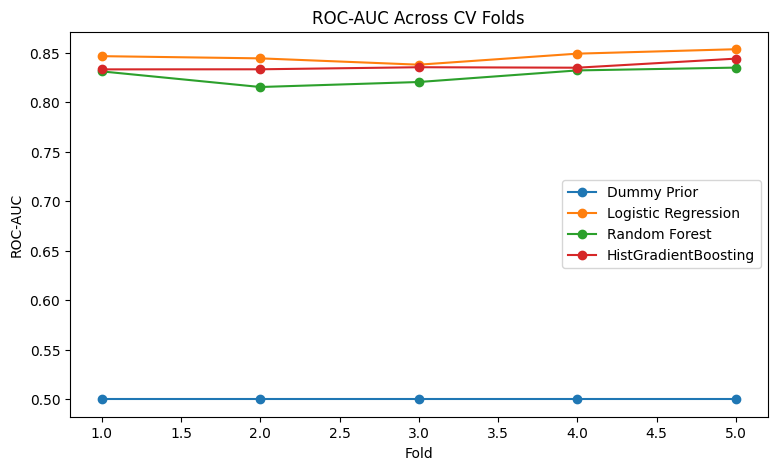

In [28]:
plt.figure(figsize=(9, 5))

for model_name in cv_score_df["Model"].unique():
    model_scores = cv_score_df[
        (cv_score_df["Model"] == model_name) &
        (cv_score_df["Metric"] == "ROC-AUC")
    ]["Score"]
    
    plt.plot(
        range(1, len(model_scores) + 1),
        model_scores,
        marker="o",
        label=model_name
    )

plt.title("ROC-AUC Across CV Folds")
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

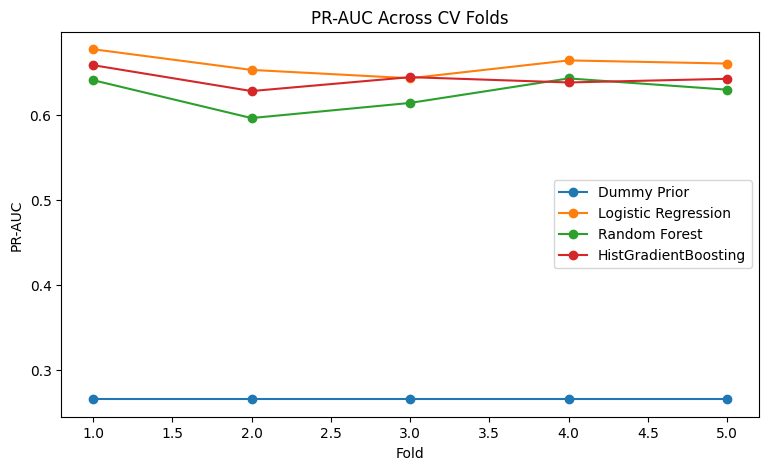

In [30]:
plt.figure(figsize=(9, 5))

for model_name in cv_score_df["Model"].unique():
    model_scores = cv_score_df[
        (cv_score_df["Model"] == model_name) &
        (cv_score_df["Metric"] == "PR-AUC")
    ]["Score"]
    
    plt.plot(
        range(1, len(model_scores) + 1),
        model_scores,
        marker="o",
        label=model_name
    )

plt.title("PR-AUC Across CV Folds")
plt.xlabel("Fold")
plt.ylabel("PR-AUC")
plt.legend()
plt.show()

## Cross-Validation Score Distribution

Looking only at the mean cross-validation score can hide instability.

By plotting scores across folds, we can see whether a model performs consistently or whether its performance changes depending on the validation fold.

A stable model should have relatively small variation across folds.

If a model has high average performance but large fold-to-fold variation, it may be less reliable than the mean score suggests.

In [31]:
rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

In [32]:
repeated_cv_rows = []

for name, pipeline in model_pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=rskf,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    repeated_cv_rows.append({
        "Model": name,
        "ROC-AUC Mean": scores.mean(),
        "ROC-AUC Std": scores.std(),
        "ROC-AUC Min": scores.min(),
        "ROC-AUC Max": scores.max(),
        "Number of Scores": len(scores)
    })

repeated_cv_df = pd.DataFrame(repeated_cv_rows).sort_values("ROC-AUC Mean", ascending=False)
repeated_cv_df

,Model,ROC-AUC Mean,ROC-AUC Std,ROC-AUC Min,ROC-AUC Max,Number of Scores
1,Logistic Regression,0.846994,0.008017,0.828808,0.858880,25
3,HistGradientBoosting,0.837928,0.005234,0.829415,0.850055,25
2,Random Forest,0.825626,0.007720,0.807640,0.836882,25
0,Dummy Prior,0.500000,0.000000,0.500000,0.500000,25


In [33]:
repeated_cv_rows = []

for name, pipeline in model_pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=rskf,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    repeated_cv_rows.append({
        "Model": name,
        "ROC-AUC Mean": scores.mean(),
        "ROC-AUC Std": scores.std(),
        "ROC-AUC Min": scores.min(),
        "ROC-AUC Max": scores.max(),
        "Number of Scores": len(scores)
    })

repeated_cv_df = pd.DataFrame(repeated_cv_rows).sort_values("ROC-AUC Mean", ascending=False)
repeated_cv_df

,Model,ROC-AUC Mean,ROC-AUC Std,ROC-AUC Min,ROC-AUC Max,Number of Scores
1,Logistic Regression,0.846994,0.008017,0.828808,0.858880,25
3,HistGradientBoosting,0.837928,0.005234,0.829415,0.850055,25
2,Random Forest,0.825626,0.007720,0.807640,0.836882,25
0,Dummy Prior,0.500000,0.000000,0.500000,0.500000,25


## Repeated Stratified K-Fold

Repeated Stratified K-Fold performs cross-validation multiple times with different fold assignments.

In this notebook, 5-fold cross-validation is repeated 5 times, producing 25 ROC-AUC scores for each model.

Logistic Regression achieved the best repeated CV ROC-AUC mean at 0.8470, with a standard deviation of 0.0080. Its scores ranged from 0.8288 to 0.8589.

HistGradientBoosting achieved a mean ROC-AUC of 0.8379 with a smaller standard deviation of 0.0052. Random Forest achieved a mean ROC-AUC of 0.8256.

The repeated cross-validation results support the earlier Stratified K-Fold results: Logistic Regression is the strongest overall model by ROC-AUC, while HistGradientBoosting is also competitive but slightly lower on average.

## Model Selection for Tuning

Based on the cross-validation results, Logistic Regression and HistGradientBoosting are selected for tuning.

Logistic Regression is selected because it achieved the best ROC-AUC and PR-AUC in both holdout validation and repeated cross-validation. It also had very small train-validation gaps, making it the most stable candidate.

HistGradientBoosting is selected because it was the strongest non-linear model and may capture feature interactions that Logistic Regression cannot.

This comparison helps determine whether the extra complexity of a boosting model provides enough benefit over a simpler linear baseline.

In [34]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_search = GridSearchCV(
    log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)

log_reg_search.fit(X_train, y_train)

print("Best Logistic Regression Params:")
print(log_reg_search.best_params_)
print("Best Logistic Regression CV ROC-AUC:")
print(log_reg_search.best_score_)

Best Logistic Regression Params:
{'model__C': 10, 'model__class_weight': None}
Best Logistic Regression CV ROC-AUC:
0.8462720772227037


In [35]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_dist = {
    "model__learning_rate": uniform(0.02, 0.18),
    "model__max_iter": randint(80, 250),
    "model__max_leaf_nodes": randint(15, 45),
    "model__l2_regularization": uniform(0.0, 1.0)
}

hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

hgb_search.fit(X_train, y_train)

print("Best HistGradientBoosting Params:")
print(hgb_search.best_params_)
print("Best HistGradientBoosting CV ROC-AUC:")
print(hgb_search.best_score_)

Best HistGradientBoosting Params:
{'model__l2_regularization': np.float64(0.6116531604882809), 'model__learning_rate': np.float64(0.021271934939549132), 'model__max_iter': 168, 'model__max_leaf_nodes': 31}
Best HistGradientBoosting CV ROC-AUC:
0.8453606452501073


## Hyperparameter Tuning with Cross-Validation

Hyperparameter tuning uses cross-validation to compare different model settings.

For Logistic Regression, the best parameters were:

- `C = 10`
- `class_weight = None`

The best Logistic Regression tuning ROC-AUC was 0.8463.

For HistGradientBoosting, the best parameters were approximately:

- `learning_rate = 0.0213`
- `max_iter = 168`
- `max_leaf_nodes = 31`
- `l2_regularization = 0.6117`

The best HistGradientBoosting tuning ROC-AUC was 0.8454.

The two tuned models are very close by ROC-AUC. Logistic Regression is slightly better, but HistGradientBoosting is competitive after tuning.

In [36]:
tuned_models = {
    "Tuned Logistic Regression": log_reg_search.best_estimator_,
    "Tuned HistGradientBoosting": hgb_search.best_estimator_
}

tuned_cv_rows = []

for name, model in tuned_models.items():
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )
    
    row = {"Model": name}
    
    for metric in scoring.keys():
        test_scores = cv_result[f"test_{metric}"]
        train_scores = cv_result[f"train_{metric}"]
        
        row[f"CV {metric} mean"] = test_scores.mean()
        row[f"CV {metric} std"] = test_scores.std()
        row[f"Train {metric} mean"] = train_scores.mean()
        row[f"Train-Test {metric} gap"] = train_scores.mean() - test_scores.mean()
    
    tuned_cv_rows.append(row)

tuned_cv_df = pd.DataFrame(tuned_cv_rows).sort_values("CV roc_auc mean", ascending=False)
tuned_cv_df

,Model,CV accuracy mean,CV accuracy std,Train accuracy mean,Train-Test accuracy gap,CV precision mean,CV precision std,Train precision mean,Train-Test precision gap,CV recall mean,CV recall std,Train recall mean,Train-Test recall gap,CV f1 mean,CV f1 std,Train f1 mean,Train-Test f1 gap,CV roc_auc mean,CV roc_auc std,Train roc_auc mean,Train-Test roc_auc gap,CV average_precision mean,CV average_precision std,Train average_precision mean,Train-Test average_precision gap
0,Tuned Logistic Regression,0.802667,0.011314,0.805600,0.002933,0.654485,0.029115,0.659458,0.004973,0.547157,0.021839,0.555351,0.008194,0.595796,0.021900,0.602935,0.007139,0.846272,0.004970,0.851393,0.005121,0.659265,0.011445,0.670175,0.010910
1,Tuned HistGradientBoosting,0.798756,0.004077,0.848267,0.049511,0.659191,0.010823,0.774366,0.115174,0.504348,0.040323,0.606187,0.101839,0.570332,0.023269,0.679839,0.109507,0.845361,0.004921,0.913194,0.067833,0.659623,0.014550,0.792604,0.132981


## Tuned Model Comparison

After hyperparameter tuning, the selected best estimators are evaluated again using Stratified K-Fold cross-validation.

Tuned Logistic Regression achieved a CV ROC-AUC of 0.8463 and a CV PR-AUC of 0.6593.

Tuned HistGradientBoosting achieved a very similar CV ROC-AUC of 0.8454 and a slightly higher CV PR-AUC of 0.6596.

However, the train-validation gaps are different. Tuned Logistic Regression had a very small ROC-AUC gap of 0.0051 and PR-AUC gap of 0.0109. Tuned HistGradientBoosting had a larger ROC-AUC gap of 0.0678 and PR-AUC gap of 0.1330.

This means HistGradientBoosting is competitive in validation performance, but Logistic Regression is more stable and less overfit. If the priority is reliability and simplicity, Logistic Regression is the safer choice. If the priority is slightly stronger positive-class ranking by PR-AUC, HistGradientBoosting can still be considered.

In [37]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

nested_log_reg_search = GridSearchCV(
    log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)

nested_scores = cross_val_score(
    nested_log_reg_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Nested CV ROC-AUC scores:")
print(nested_scores)
print("Nested CV mean:", nested_scores.mean())
print("Nested CV std:", nested_scores.std())

Nested CV ROC-AUC scores:
[0.85065634 0.83102067 0.84130718 0.8514702  0.85600104]
Nested CV mean: 0.8460910865111307
Nested CV std: 0.008921732646419052


In [38]:
small_hgb_param_dist = {
    "model__learning_rate": uniform(0.03, 0.12),
    "model__max_iter": randint(80, 180),
    "model__max_leaf_nodes": randint(15, 35),
}

nested_hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=small_hgb_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1
)

nested_hgb_scores = cross_val_score(
    nested_hgb_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Nested HGB CV ROC-AUC scores:")
print(nested_hgb_scores)
print("Nested HGB CV mean:", nested_hgb_scores.mean())
print("Nested HGB CV std:", nested_hgb_scores.std())

Nested HGB CV ROC-AUC scores:
[0.85617312 0.8377562  0.8415481  0.85032433 0.85975852]
Nested HGB CV mean: 0.8491120522808068
Nested HGB CV std: 0.00837668487737304


## Nested Cross-Validation

Nested cross-validation separates hyperparameter tuning from performance estimation.

The inner cross-validation loop selects the best hyperparameters. The outer cross-validation loop estimates how well that whole model selection process generalizes.

For Logistic Regression, the nested CV ROC-AUC scores were approximately:

```text
0.8507, 0.8310, 0.8413, 0.8515, 0.8560

In [39]:
final_model = hgb_search.best_estimator_
final_model_name = "Tuned HistGradientBoosting"

In [40]:
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)[:, 1]

print_model_report(final_model_name, y_test, test_pred, test_prob)

Tuned HistGradientBoosting
Confusion Matrix:
[[919 114]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8355    0.8896    0.8617      1033
           1     0.6287    0.5160    0.5668       374

    accuracy                         0.7903      1407
   macro avg     0.7321    0.7028    0.7143      1407
weighted avg     0.7805    0.7903    0.7833      1407

ROC-AUC: 0.8359419892219846
PR-AUC: 0.650698958855123


In [41]:
final_test_results = pd.DataFrame([
    evaluate_predictions(final_model_name, y_test, test_pred, test_prob)
])

final_test_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned HistGradientBoosting,0.790334,0.628664,0.516043,0.566814,0.835942,0.650699


## Final Test Evaluation

The final selected model is Tuned HistGradientBoosting.

After model selection and tuning, the final model is fitted on the full training set and evaluated once on the untouched test set.

The final test accuracy is 0.7903. The final test precision is 0.6287, recall is 0.5160, and F1-score is 0.5668.

The final test ROC-AUC is 0.8359, and the final test PR-AUC is 0.6507.

This test score is the most important estimate because the test set was not used during model comparison or hyperparameter tuning.

The final test ROC-AUC is slightly lower than the nested CV mean for HistGradientBoosting, but it is still reasonably close. This suggests that the validation strategy gave a useful estimate of generalization performance, although the final test set was slightly more difficult than the average cross-validation split.

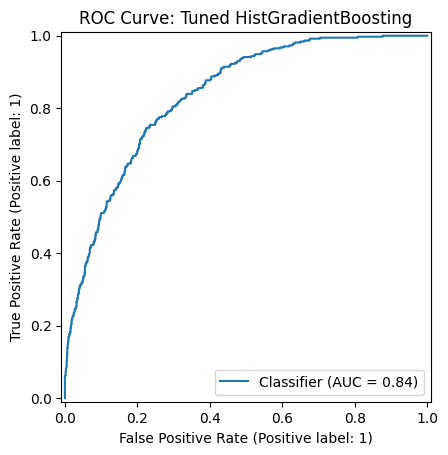

In [42]:
RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title(f"ROC Curve: {final_model_name}")
plt.show()

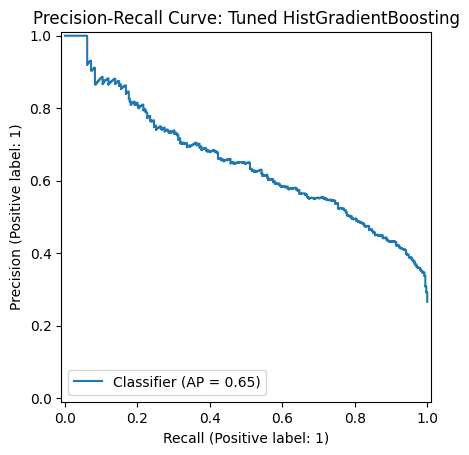

In [43]:
PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title(f"Precision-Recall Curve: {final_model_name}")
plt.show()

## Final ROC and Precision-Recall Curves

The ROC curve shows how the true positive rate changes against the false positive rate across classification thresholds.

The precision-recall curve focuses on the positive class and is especially useful when churners are less common than non-churners.

These curves help evaluate the model as a ranking system, not only as a fixed-threshold classifier.

In [44]:
def bootstrap_metric_ci(y_true, y_prob, metric_func, n_bootstraps=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    scores = []
    
    for _ in range(n_bootstraps):
        indices = rng.choice(len(y_true), size=len(y_true), replace=True)
        
        # Some bootstrap samples may contain only one class, skip them
        if len(np.unique(y_true[indices])) < 2:
            continue
        
        score = metric_func(y_true[indices], y_prob[indices])
        scores.append(score)
    
    scores = np.array(scores)
    
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    
    return scores, lower, upper

In [45]:
roc_bootstrap_scores, roc_lower, roc_upper = bootstrap_metric_ci(
    y_test,
    test_prob,
    roc_auc_score,
    n_bootstraps=1000,
    random_state=42
)

print("Bootstrap ROC-AUC 95% CI:")
print(roc_lower, roc_upper)

Bootstrap ROC-AUC 95% CI:
0.813219274290423 0.8562965721061441


In [46]:
pr_bootstrap_scores, pr_lower, pr_upper = bootstrap_metric_ci(
    y_test,
    test_prob,
    average_precision_score,
    n_bootstraps=1000,
    random_state=42
)

print("Bootstrap PR-AUC 95% CI:")
print(pr_lower, pr_upper)

Bootstrap PR-AUC 95% CI:
0.6018232790489544 0.6982338290697809


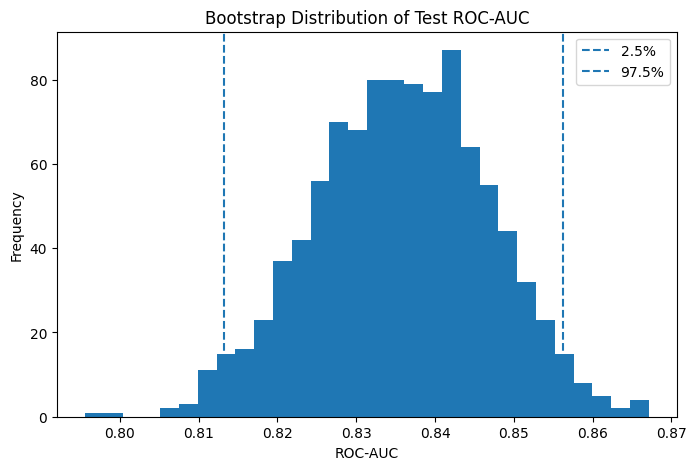

In [47]:
plt.figure(figsize=(8, 5))
plt.hist(roc_bootstrap_scores, bins=30)
plt.axvline(roc_lower, linestyle="--", label="2.5%")
plt.axvline(roc_upper, linestyle="--", label="97.5%")
plt.title("Bootstrap Distribution of Test ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Bootstrap Confidence Interval

A single test score is only one estimate of model performance.

Bootstrap resampling estimates how much the test score might vary if we sampled similar test sets from the same population.

The 95% bootstrap confidence interval for test ROC-AUC is approximately 0.8132 to 0.8563.

The 95% bootstrap confidence interval for test PR-AUC is approximately 0.6018 to 0.6982.

This shows that the model’s ranking performance is reasonably strong, but there is still uncertainty around the exact test-set score.

The PR-AUC interval is wider than the ROC-AUC interval, which is expected because PR-AUC is more sensitive to the positive churn class and class imbalance.

In [48]:
def threshold_report(y_true, y_prob, thresholds):
    rows = []
    
    for threshold in thresholds:
        preds = (y_prob >= threshold).astype(int)
        
        rows.append({
            "Threshold": threshold,
            "Predicted Churners": preds.sum(),
            "Accuracy": accuracy_score(y_true, preds),
            "Precision": precision_score(y_true, preds, zero_division=0),
            "Recall": recall_score(y_true, preds, zero_division=0),
            "F1": f1_score(y_true, preds, zero_division=0),
        })
    
    return pd.DataFrame(rows)

thresholds = np.round(np.arange(0.1, 0.91, 0.1), 2)

thresholds_df = threshold_report(y_test, test_prob, thresholds)
thresholds_df

,Threshold,Predicted Churners,Accuracy,Precision,Recall,F1
0,0.1,907,0.594172,0.391400,0.949198,0.554254
1,0.2,683,0.699360,0.464129,0.847594,0.599811
2,0.3,547,0.751955,0.522852,0.764706,0.621064
3,0.4,411,0.780384,0.579075,0.636364,0.606369
4,0.5,307,0.790334,0.628664,0.516043,0.566814
5,0.6,203,0.790334,0.694581,0.377005,0.488735
6,0.7,121,0.778962,0.760331,0.245989,0.371717
7,0.8,58,0.765458,0.879310,0.136364,0.236111
8,0.9,0,0.734186,0.000000,0.000000,0.000000


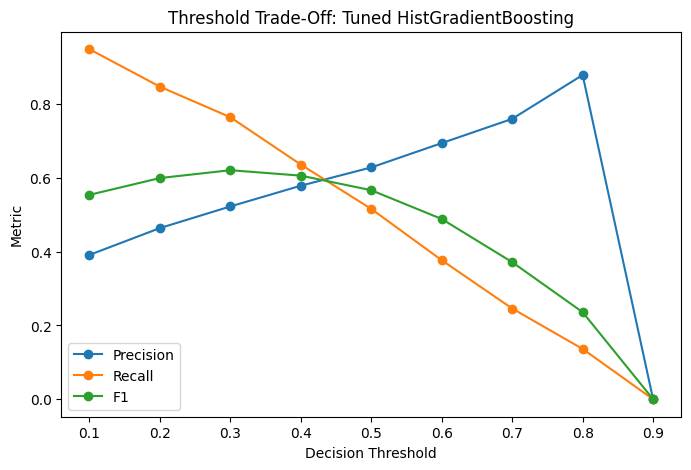

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds_df["Threshold"], thresholds_df["Precision"], marker="o", label="Precision")
plt.plot(thresholds_df["Threshold"], thresholds_df["Recall"], marker="o", label="Recall")
plt.plot(thresholds_df["Threshold"], thresholds_df["F1"], marker="o", label="F1")
plt.title(f"Threshold Trade-Off: {final_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.legend()
plt.show()

## Threshold Tuning

The default classification threshold is 0.5, but this is not always the best decision threshold.

At threshold 0.5, the model predicts 307 customers as churners, with precision of 0.6287, recall of 0.5160, and F1-score of 0.5668.

The best F1-score in the threshold table occurs at threshold 0.3, where the model predicts 547 churners and achieves precision of 0.5229, recall of 0.7647, and F1-score of 0.6211.

This shows that the default 0.5 threshold is not optimal if the goal is to balance precision and recall.

For churn prediction, a lower threshold may be preferred because it captures more actual churners. However, this also means more customers will be flagged for retention action, including more false positives.

The best threshold depends on the business goal. If the company wants to catch as many churners as possible, recall is more important. If retention offers are expensive, precision may be more important.

In [50]:
lift_df = pd.DataFrame({
    "ActualChurn": y_test.values,
    "PredictedProbability": test_prob
})

lift_df = lift_df.sort_values("PredictedProbability", ascending=False).reset_index(drop=True)

lift_df["Decile"] = pd.qcut(
    lift_df.index + 1,
    q=10,
    labels=[f"Top {i*10}%" for i in range(1, 11)]
)

lift_summary = lift_df.groupby("Decile").agg(
    Customers=("ActualChurn", "count"),
    Churners=("ActualChurn", "sum"),
    ChurnRate=("ActualChurn", "mean"),
    AveragePredictedProbability=("PredictedProbability", "mean")
).reset_index()

lift_summary

,Decile,Customers,Churners,ChurnRate,AveragePredictedProbability
0,Top 10%,141,104,0.737589,0.774640
1,Top 20%,141,79,0.560284,0.594952
2,Top 30%,140,59,0.421429,0.452562
3,Top 40%,141,48,0.340426,0.338031
4,Top 50%,141,30,0.212766,0.232461
5,Top 60%,140,28,0.200000,0.154274
6,Top 70%,141,14,0.099291,0.097928
7,Top 80%,140,10,0.071429,0.042963
8,Top 90%,141,1,0.007092,0.024304
9,Top 100%,141,1,0.007092,0.019089


In [51]:
overall_churn_rate = y_test.mean()

lift_summary["Lift"] = lift_summary["ChurnRate"] / overall_churn_rate
lift_summary

,Decile,Customers,Churners,ChurnRate,AveragePredictedProbability,Lift
0,Top 10%,141,104,0.737589,0.774640,2.774832
1,Top 20%,141,79,0.560284,0.594952,2.107805
2,Top 30%,140,59,0.421429,0.452562,1.585428
3,Top 40%,141,48,0.340426,0.338031,1.280692
4,Top 50%,141,30,0.212766,0.232461,0.800432
5,Top 60%,140,28,0.200000,0.154274,0.752406
6,Top 70%,141,14,0.099291,0.097928,0.373535
7,Top 80%,140,10,0.071429,0.042963,0.268717
8,Top 90%,141,1,0.007092,0.024304,0.026681
9,Top 100%,141,1,0.007092,0.019089,0.026681


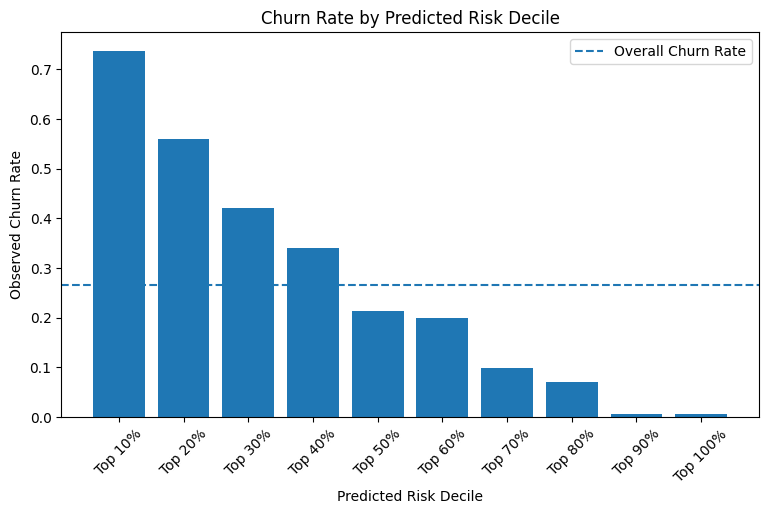

In [52]:
plt.figure(figsize=(9, 5))
plt.bar(lift_summary["Decile"], lift_summary["ChurnRate"])
plt.axhline(overall_churn_rate, linestyle="--", label="Overall Churn Rate")
plt.title("Churn Rate by Predicted Risk Decile")
plt.xlabel("Predicted Risk Decile")
plt.ylabel("Observed Churn Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Lift Analysis

Lift analysis checks whether the model successfully ranks customers by churn risk.

Customers are sorted by predicted churn probability and divided into ten equally sized groups.

The highest-risk decile has a churn rate of 73.76%, compared with the overall test-set churn rate of 26.58%.

This gives a lift of approximately 2.77.

This means customers in the top 10% predicted-risk group are about 2.77 times more likely to churn than the average customer in the test set.

The lift table also shows a strong ranking pattern. The top 20% group has a churn rate of 56.03%, and the top 30% group has a churn rate of 42.14%. Churn rate decreases sharply in the lower-risk groups.

This shows that the model is useful for prioritizing customers for retention campaigns, even if the classification threshold is not perfect.